In [1]:
# imports
import sqlite3
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import scipy.stats as stats
import seaborn as sns 

## 1. Data extraction

In [2]:
# 1. Establish SQLite Connection
db_path = "/Users/usuario/Documents/GitHub/f1-race-analytics/data/Formula1.sqlite"  
conn = sqlite3.connect(db_path)

# 2. Extract Data for Grid vs. Finish & Win Probability
query_results = """
SELECT 
    r.raceId,
    r.year,
    r.circuitId,
    res.driverId,
    res.constructorId,
    res.grid,
    res.positionOrder AS final_position,
    res.statusId
FROM results res
JOIN races r ON res.raceId = r.raceId
WHERE res.grid > 0; -- Exclude pit lane starts or invalid grid entries
"""

df_results = pd.read_sql_query(query_results, conn)

# 3. Extract Data for Pitstop Analysis
query_pitstops = """
SELECT 
    p.raceId,
    r.year,
    p.driverId,
    res.constructorId,
    c.name AS constructor_name,
    p.stop,
    p.lap,
    p.duration,
    p.milliseconds AS pit_ms
FROM pitstops p
JOIN races r ON p.raceId = r.raceId
JOIN results res ON p.raceId = res.raceId AND p.driverId = res.driverId
JOIN constructors c ON res.constructorId = c.constructorId;
"""

df_pitstops = pd.read_sql_query(query_pitstops, conn)

# 4. Safely Close Connection
conn.close()

# 5. Quick verification check
print("Results Shape:", df_results.shape)
print("Pitstops Shape:", df_pitstops.shape)
print("-------------------Extract Data for Grid vs. Finish & Win Probability---------------")
display(df_results.head())
print(df_results.info)
print("-------------------------------Data for Pitstop Analysis-----------------------------------")
display(df_pitstops.head())
print(df_pitstops.info)

Results Shape: (22211, 8)
Pitstops Shape: (6251, 9)
-------------------Extract Data for Grid vs. Finish & Win Probability---------------


,raceId,year,circuitId,driverId,constructorId,grid,final_position,statusId
0,18,2008,1,1,1,1,1,1
1,18,2008,1,2,2,5,2,1
2,18,2008,1,3,3,7,3,1
3,18,2008,1,4,4,11,4,1
4,18,2008,1,5,1,3,5,1


<bound method DataFrame.info of        raceId  year  circuitId  driverId  constructorId  grid  final_position  \
0          18  2008          1         1              1     1               1   
1          18  2008          1         2              2     5               2   
2          18  2008          1         3              3     7               3   
3          18  2008          1         4              4    11               4   
4          18  2008          1         5              1     3               5   
...       ...   ...        ...       ...            ...   ...             ...   
22206     988  2017         24       842              5    17              16   
22207     988  2017         24       828             15    19              17   
22208     988  2017         24       840              3    15              18   
22209     988  2017         24       832              4    12              19   
22210     988  2017         24       817              9     4              20

,raceId,year,driverId,constructorId,constructor_name,stop,lap,duration,pit_ms
0,841,2011,1,1,McLaren,1,16,23.227,23227
1,841,2011,1,1,McLaren,2,36,23.199,23199
2,841,2011,18,1,McLaren,1,17,16.867,16867
3,841,2011,18,1,McLaren,2,19,23.303,23303
4,841,2011,18,1,McLaren,3,37,22.681,22681


<bound method DataFrame.info of       raceId  year  driverId  constructorId constructor_name  stop  lap  \
0        841  2011         1              1          McLaren     1   16   
1        841  2011         1              1          McLaren     2   36   
2        841  2011        18              1          McLaren     1   17   
3        841  2011        18              1          McLaren     2   19   
4        841  2011        18              1          McLaren     3   37   
...      ...   ...       ...            ...              ...   ...  ...   
6246     987  2017       154            210     Haas F1 Team     2    2   
6247     987  2017       154            210     Haas F1 Team     3    3   
6248     987  2017       154            210     Haas F1 Team     4   48   
6249     988  2017       154            210     Haas F1 Team     1   32   
6250     988  2017       825            210     Haas F1 Team     1   22   

     duration  pit_ms  
0      23.227   23227  
1      23.199   231

## 2. Statistical EDA and modeling 

Pearson Correlation: 0.427 (p-value: 0.000e+00)
Spearman Correlation: 0.436 (p-value: 0.000e+00)


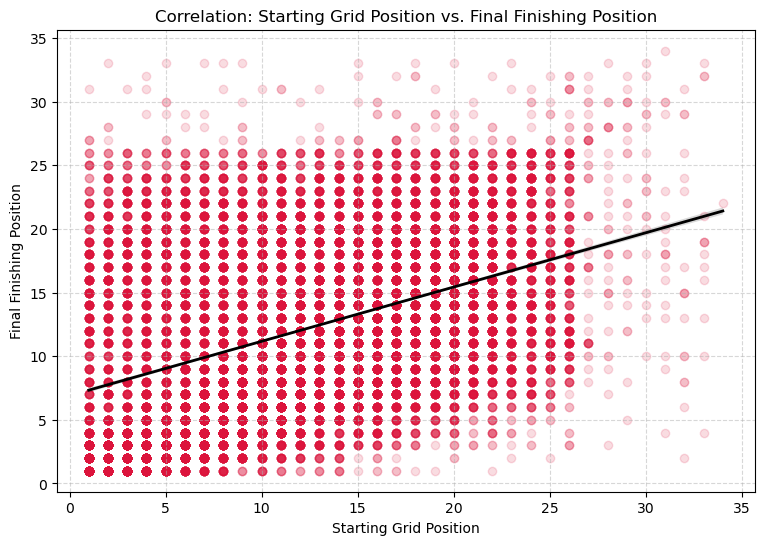

In [3]:
# 1. Clean / Filter data (exclude grid position 0, which usually denotes pit lane or non-qualifiers)
clean_results = df_results[
    (df_results["grid"] > 0) & (df_results["final_position"].notnull())
].copy()

# 2. Compute Pearson and Spearman correlations
pearson_corr, pearson_p = stats.pearsonr(
    clean_results["grid"], clean_results["final_position"]
)
spearman_corr, spearman_p = stats.spearmanr(
    clean_results["grid"], clean_results["final_position"]
)

print(f"Pearson Correlation: {pearson_corr:.3f} (p-value: {pearson_p:.3e})")
print(f"Spearman Correlation: {spearman_corr:.3f} (p-value: {spearman_p:.3e})")

# 3. Visualization
plt.figure(figsize=(9, 6))
sns.regplot(
    data=clean_results,
    x="grid",
    y="final_position",
    scatter_kws={"alpha": 0.15, "color": "crimson"},
    line_kws={"color": "black", "linewidth": 2},
)
plt.title("Correlation: Starting Grid Position vs. Final Finishing Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Final Finishing Position")
plt.grid(True, linestyle="--", alpha=0.5)

# Save visualization for GitHub presentation
plt.savefig("../visuals/grid_vs_finish_correlation.png", dpi=300)
plt.show()

### Win Probablity modeling 

   grid  total_starts  total_wins  win_probability
0     1           986         407         0.412779
1     2           977         232         0.237462
2     3           981         120         0.122324
3     4           983          62         0.063072
4     5           983          47         0.047813
5     6           976          35         0.035861
6     7           987          22         0.022290
7     8           981          16         0.016310
8     9           983           4         0.004069
9    10           983           9         0.009156


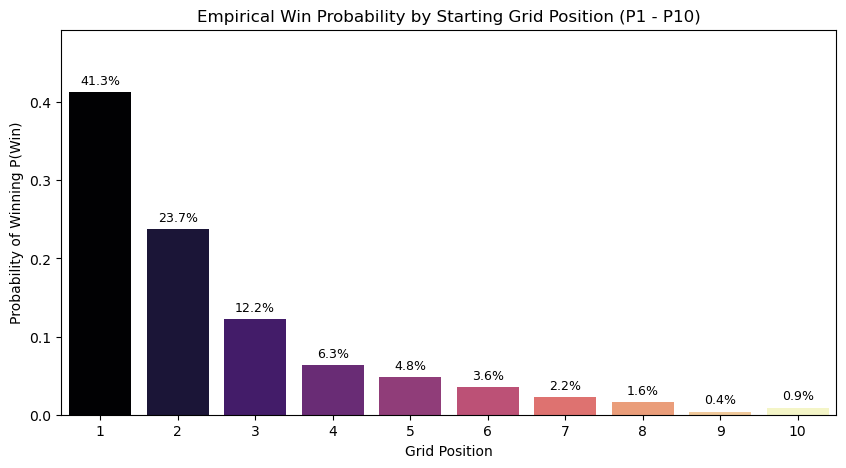

In [4]:
# 1. Create binary indicator
clean_results["is_win"] = (clean_results["final_position"] == 1).astype(int)

# 2. Group by grid position (e.g., top 10 positions)
grid_stats = (
    clean_results[clean_results["grid"] <= 10]
    .groupby("grid")
    .agg(
        total_starts=("is_win", "count"),
        total_wins=("is_win", "sum"),
        win_probability=("is_win", "mean"),
    )
    .reset_index()
)

print(grid_stats)

# 3. Visualization: Probability Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=grid_stats,
    x="grid",
    y="win_probability",
    palette="magma",
    hue="grid",
    legend=False,
)
plt.title("Empirical Win Probability by Starting Grid Position (P1 - P10)")
plt.xlabel("Grid Position")
plt.ylabel("Probability of Winning P(Win)")

# Annotate percentages on top of bars
for index, row in grid_stats.iterrows():
    plt.text(
        index,
        row["win_probability"] + 0.01,
        f"{row['win_probability']*100:.1f}%",
        ha="center",
        fontsize=9,
    )

plt.ylim(0, max(grid_stats["win_probability"]) + 0.08)
plt.savefig("../visuals/win_probability_by_grid.png", dpi=300)
plt.show()

### Pitstop Duration EDA & Statistical hypothesis testing 

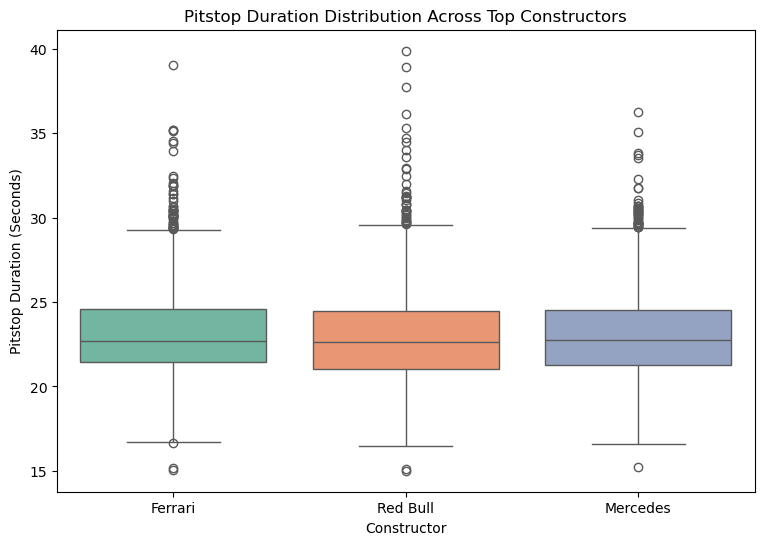

Kruskal-Wallis H-statistic: 0.724
p-value: 6.964e-01
Conclusion: Fail to reject H0 — No statistically significant difference detected.


In [5]:
# 1. Convert to seconds and filter realistic pit stop range
df_pitstops["duration_sec"] = df_pitstops["pit_ms"] / 1000.0
valid_pits = df_pitstops[
    (df_pitstops["duration_sec"] >= 15) & (df_pitstops["duration_sec"] <= 40)
].copy()

# 2. Select top teams for comparison (e.g., Mercedes, Ferrari, Red Bull)
top_teams = ["Mercedes", "Ferrari", "Red Bull"]
filtered_pits = valid_pits[valid_pits["constructor_name"].isin(top_teams)]

# 3. Violin plot or Box plot for team comparison
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=filtered_pits,
    x="constructor_name",
    y="duration_sec",
    palette="Set2",
    hue="constructor_name",
)
plt.title("Pitstop Duration Distribution Across Top Constructors")
plt.xlabel("Constructor")
plt.ylabel("Pitstop Duration (Seconds)")
plt.savefig("../visuals/pitstop_duration_by_team.png", dpi=300)
plt.show()

# 4. Perform Kruskal-Wallis H-test
team_data = [
    group["duration_sec"].values
    for _, group in filtered_pits.groupby("constructor_name")
]
h_stat, p_val = stats.kruskal(*team_data)

print(f"Kruskal-Wallis H-statistic: {h_stat:.3f}")
print(f"p-value: {p_val:.3e}")

if p_val < 0.05:
    print(
        "Conclusion: Reject H0 — There is a statistically significant difference in pitstop times among teams."
    )
else:
    print(
        "Conclusion: Fail to reject H0 — No statistically significant difference detected."
    )